<a href="https://colab.research.google.com/github/Abhi0129n/Machine-learning-/blob/main/Polynomial%20regression%20curve%20fitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
housing = fetch_california_housing(as_frame=True)

# Take a sample for faster execution
df = housing.frame.sample(n=3000, random_state=42)

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


In [ ]:
print("First 5 Rows")
print(df.head())

First 5 Rows
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20046  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
3024   2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
15663  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
20484  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   
9814   3.7250      34.0  5.492991   1.028037      1063.0  2.483645     36.62   

       Longitude  MedHouseVal  
20046    -119.01      0.47700  
3024     -119.46      0.45800  
15663    -122.44      5.00001  
20484    -118.72      2.18600  
9814     -121.93      2.78000  


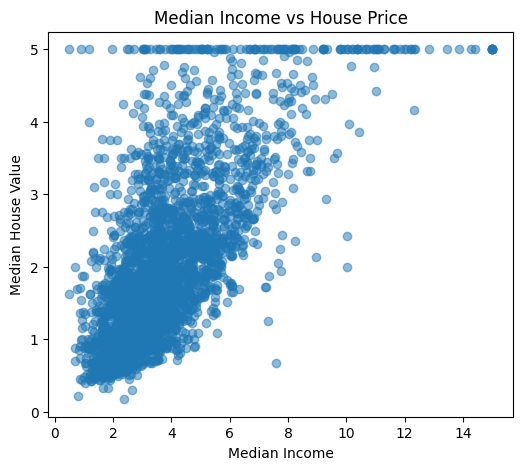

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Price")
plt.show()

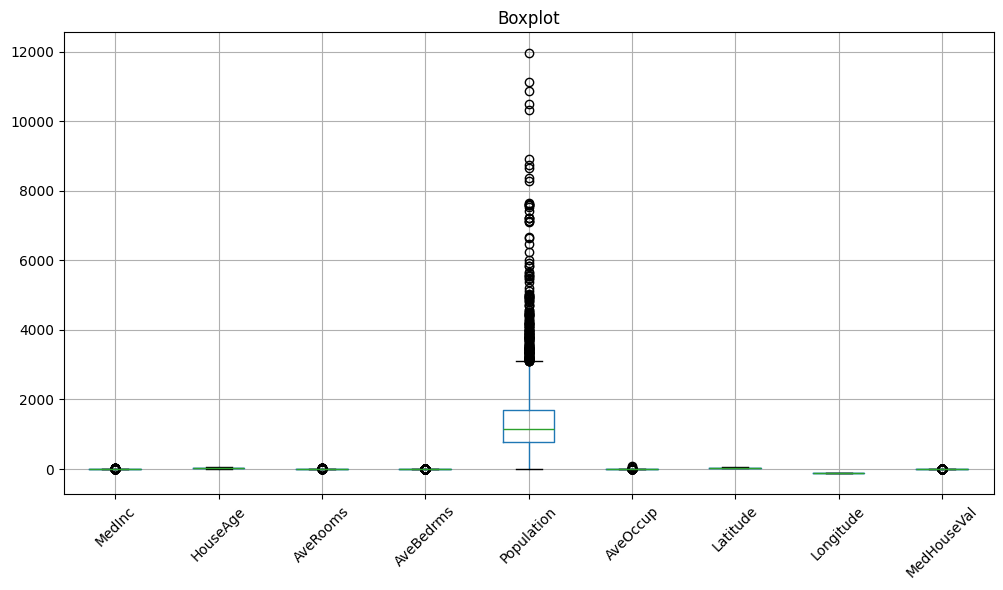

In [ ]:
plt.figure(figsize=(12,6))
df.boxplot(rot=45)
plt.title("Boxplot")
plt.show()

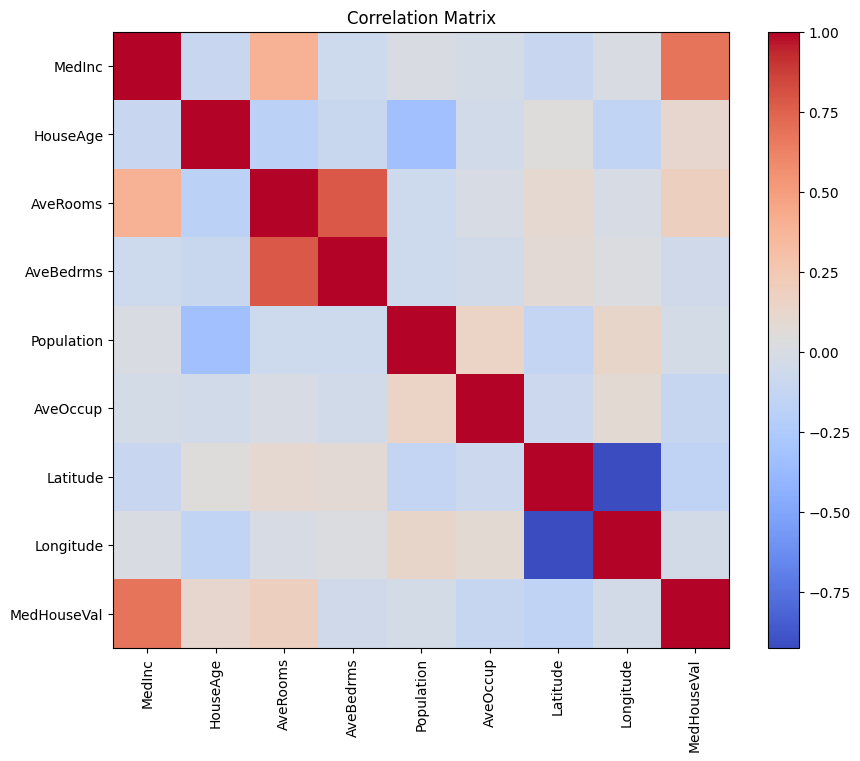

In [ ]:

corr = df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
print("\nCorrelation Matrix")
print(df.corr())


Correlation Matrix
               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.102714  0.388986  -0.070158    0.002178 -0.027994   
HouseAge    -0.102714  1.000000 -0.178749  -0.097210   -0.326319 -0.043106   
AveRooms     0.388986 -0.178749  1.000000   0.788883   -0.075109 -0.014282   
AveBedrms   -0.070158 -0.097210  0.788883   1.000000   -0.074403 -0.044461   
Population   0.002178 -0.326319 -0.075109  -0.074403    1.000000  0.155622   
AveOccup    -0.027994 -0.043106 -0.014282  -0.044461    0.155622  1.000000   
Latitude    -0.102514  0.043236  0.103317   0.081882   -0.134501 -0.078324   
Longitude    0.003500 -0.146162 -0.012827   0.021571    0.131055  0.084147   
MedHouseVal  0.683411  0.117398  0.183052  -0.056640   -0.028165 -0.107957   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.102514   0.003500     0.683411  
HouseAge     0.043236  -0.146162     0.117398  
AveRooms     0.103317  -0.012827     0.183052  
AveBedr

In [ ]:
# ==========================

degrees = range(1,11)

train_mse = []
test_mse = []

results = []

best_degree = None
best_model = None

lowest_error = float("inf")

for degree in degrees:

    print(f"\nTraining Degree {degree}")

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree,
                                    include_bias=False)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_test, test_pred)

    train_mse.append(train_error)
    test_mse.append(test_error)

    rmse = np.sqrt(test_error)
    mae = mean_absolute_error(y_test, test_pred)
    r2 = r2_score(y_test, test_pred)

    results.append([
        degree,
        test_error,
        rmse,
        mae,
        r2
    ])

    if test_error < lowest_error:
        lowest_error = test_error
        best_degree = degree
        best_model = model



Training Degree 1

Training Degree 2

Training Degree 3

Training Degree 4

Training Degree 5

Training Degree 6

Training Degree 7

Training Degree 8

Training Degree 9

Training Degree 10


In [ ]:

results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "MSE",
        "RMSE",
        "MAE",
        "R2 Score"
    ]
)

print("\nPolynomial Regression Results")
print(results_df)


Polynomial Regression Results
   Degree           MSE           RMSE           MAE      R2 Score
0       1  4.887336e-01       0.699095      0.524499  6.252492e-01
1       2  3.964759e-01       0.629663      0.463098  6.959904e-01
2       3  5.860352e-01       0.765529      0.462724  5.506403e-01
3       4  1.601319e+02      12.654324      1.411936 -1.217859e+02
4       5  1.070888e+06    1034.837025     65.706868 -8.211336e+05
5       6  4.069020e+11  637888.715264  28757.341080 -3.120041e+11
6       7  6.411279e+10  253205.031611  11202.499025 -4.916037e+10
7       8  1.313823e+10  114622.123220   4822.594244 -1.007413e+10
8       9  6.740689e+08   25962.836118   1109.203258 -5.168621e+08
9      10  4.794013e+07    6923.881399    311.638582 -3.675951e+07


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


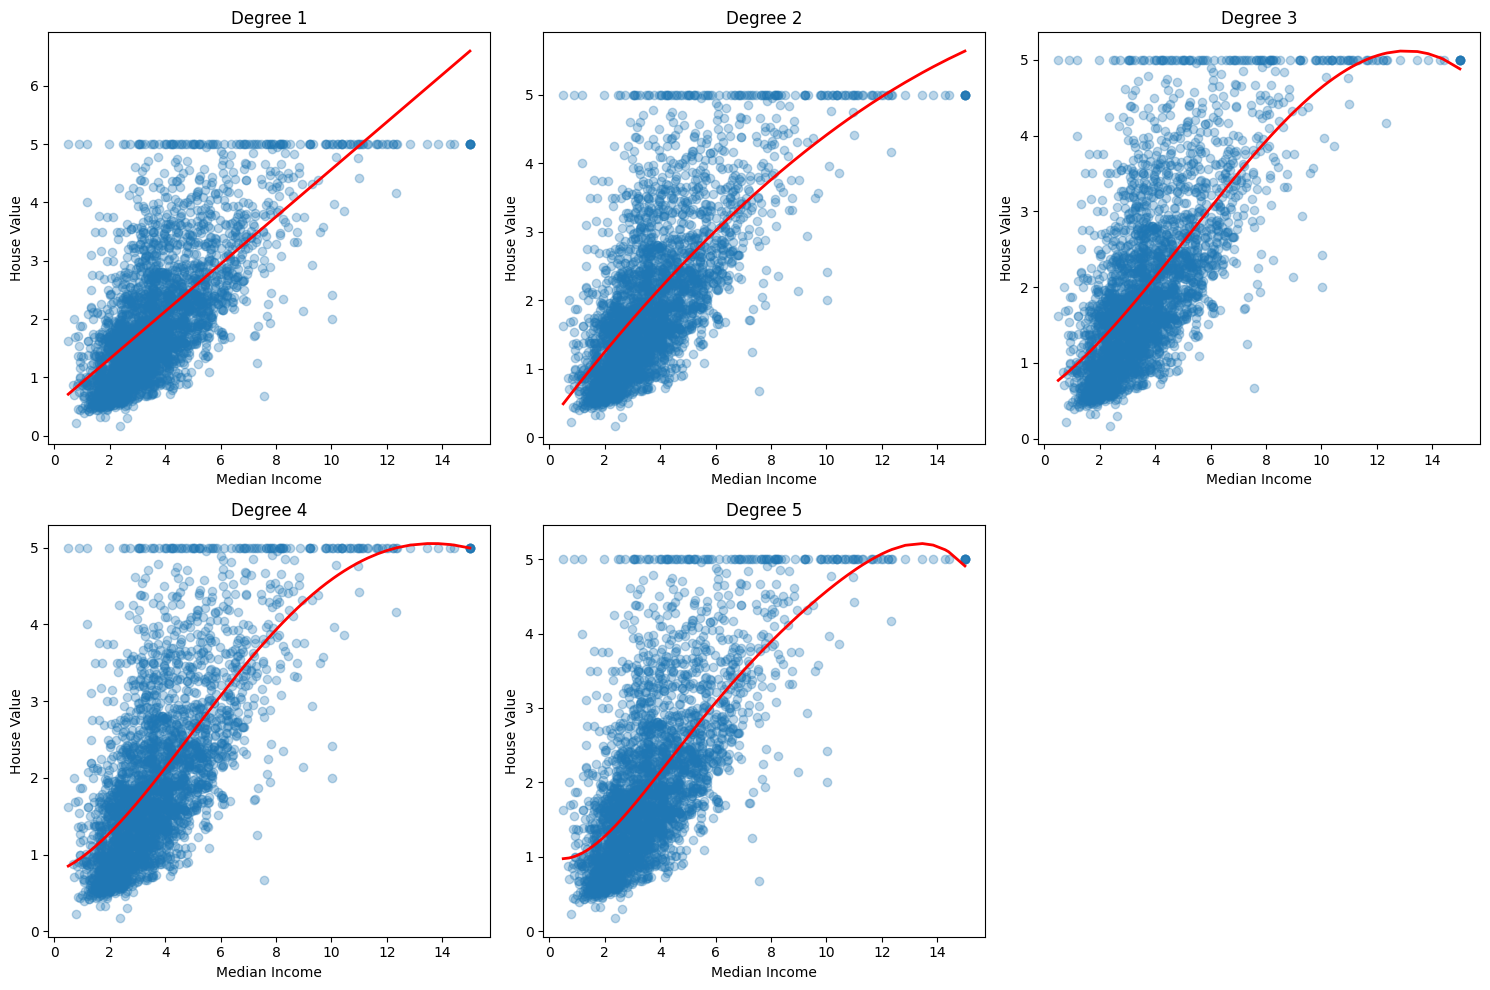

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[['MedInc']]
y = df['MedHouseVal']

degrees = [1, 2, 3, 4, 5]

plt.figure(figsize=(15,10))

for i, degree in enumerate(degrees):

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    X_sorted = np.sort(X.values, axis=0)
    X_sorted_poly = poly.transform(X_sorted)

    y_pred = model.predict(X_sorted_poly)

    plt.subplot(2,3,i+1)

    plt.scatter(X, y, alpha=0.3)
    plt.plot(X_sorted, y_pred, color='red', linewidth=2)

    plt.title(f"Degree {degree}")
    plt.xlabel("Median Income")
    plt.ylabel("House Value")

plt.tight_layout()
plt.show()

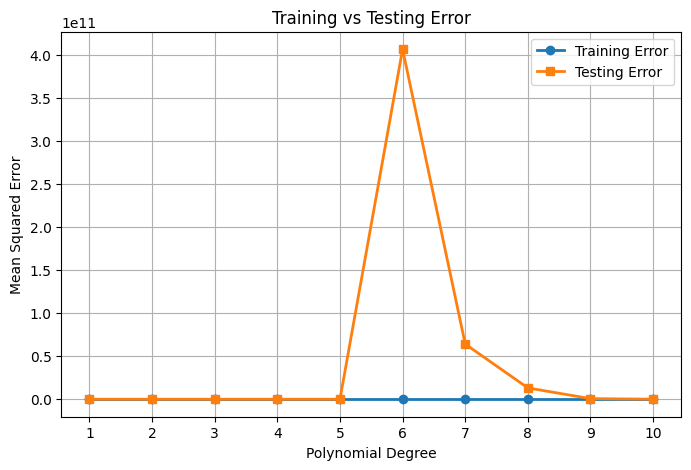

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_mse,
    marker="o",
    linewidth=2,
    label="Training Error"
)

plt.plot(
    degrees,
    test_mse,
    marker="s",
    linewidth=2,
    label="Testing Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")

plt.title("Training vs Testing Error")

plt.xticks(degrees)
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
print("\nBest Polynomial Degree:", best_degree)

best_pred = best_model.predict(X_test)

poly_mse = mean_squared_error(y_test, best_pred)
poly_rmse = np.sqrt(poly_mse)
poly_mae = mean_absolute_error(y_test, best_pred)
poly_r2 = r2_score(y_test, best_pred)

print("\nBest Polynomial Regression")

print("MSE :", poly_mse)
print("RMSE:", poly_rmse)
print("MAE :", poly_mae)
print("R2  :", poly_r2)


Best Polynomial Degree: 2

Best Polynomial Regression
MSE : 0.3964759411272583
RMSE: 0.6296633553949748
MAE : 0.46309750785066645
R2  : 0.6959904024028977


In [ ]:

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("\nLinear Regression")

print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("MAE :", linear_mae)
print("R2  :", linear_r2)


Linear Regression
MSE : 0.4887335567508983
RMSE: 0.6990948124188151
MAE : 0.5244987197966391
R2  : 0.6252491601442444


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        f"Polynomial Degree {best_degree}"
    ],

    "MSE":[
        linear_mse,
        poly_mse
    ],

    "RMSE":[
        linear_rmse,
        poly_rmse
    ],

    "MAE":[
        linear_mae,
        poly_mae
    ],

    "R2 Score":[
        linear_r2,
        poly_r2
    ]

})

print("\nComparison of Models")
print(comparison)


Comparison of Models
                 Model       MSE      RMSE       MAE  R2 Score
0    Linear Regression  0.488734  0.699095  0.524499  0.625249
1  Polynomial Degree 2  0.396476  0.629663  0.463098  0.695990
